In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

from IPython.display import display

In [19]:
OUTPUT = Path("visualization")

y_true = np.load(OUTPUT/"y_true.npy")
y_pred = np.load(OUTPUT/"y_pred.npy")
y_prob = np.load(OUTPUT/"y_prob.npy")

metadata = pd.read_csv(
    OUTPUT/"test_metadata.csv"
)

print(len(y_true))
print(len(metadata))

37718
37718


In [20]:
metadata = metadata.copy()

metadata["y_true"] = y_true
metadata["y_pred"] = y_pred
metadata["correct"] = (
    metadata.y_true == metadata.y_pred
)

metadata.head()
metadata.columns

Index(['Subject', 'Night', 'start_epoch', 'end_epoch', 'y_true', 'y_pred',
       'correct'],
      dtype='str')

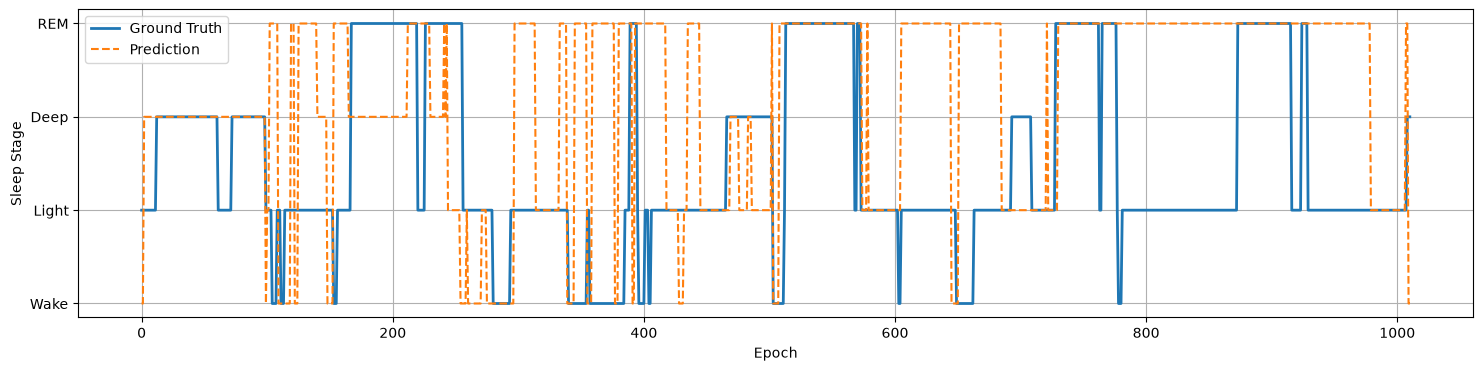

In [21]:
subject = "Bidslab14"

night = 1

df = metadata[
    (metadata.Subject==subject)
    &
    (metadata.Night==night)
].copy()

plt.figure(figsize=(18,4))

plt.plot(
    df.y_true.values,
    label="Ground Truth",
    linewidth=2
)

plt.plot(
    df.y_pred.values,
    "--",
    label="Prediction",
)

plt.yticks(
    [0,1,2,3],
    ["Wake","Light","Deep","REM"]
)

plt.xlabel("Epoch")

plt.ylabel("Sleep Stage")

plt.legend()

plt.grid(True)

plt.show()

/tmp/ipykernel_74197/3558745902.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


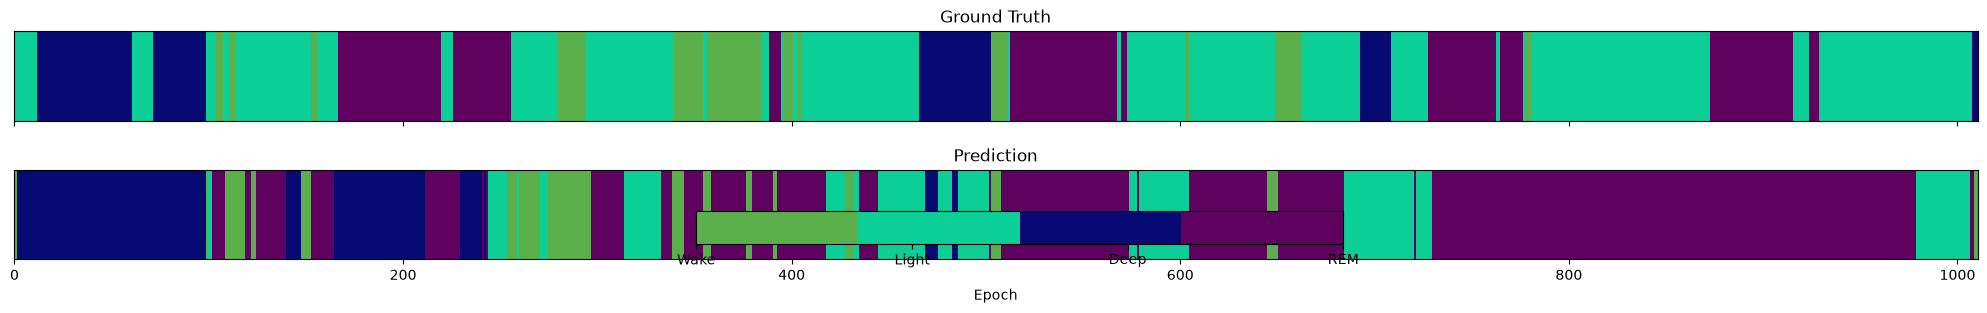

In [ ]:
from matplotlib.colors import ListedColormap

# Class mapping
# 0 = Wake
# 1 = Light
# 2 = Deep
# 3 = REM

cmap = ListedColormap([
    "#5BB04C",   # Wake
    "#0CCE97",   # Light
    "#070A72",   # Deep
    "#5F015F",   # REM
])

fig, ax = plt.subplots(
    2,
    1,
    figsize=(20, 2.8),
    sharex=True
)

# Ground Truth
im = ax[0].imshow(
    df.y_true.values.reshape(1, -1),
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=3,
)

ax[0].set_title("Ground Truth")
ax[0].set_yticks([])

# Prediction
ax[1].imshow(
    df.y_pred.values.reshape(1, -1),
    cmap=cmap,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=3,
)

ax[1].set_title("Prediction")
ax[1].set_yticks([])
ax[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

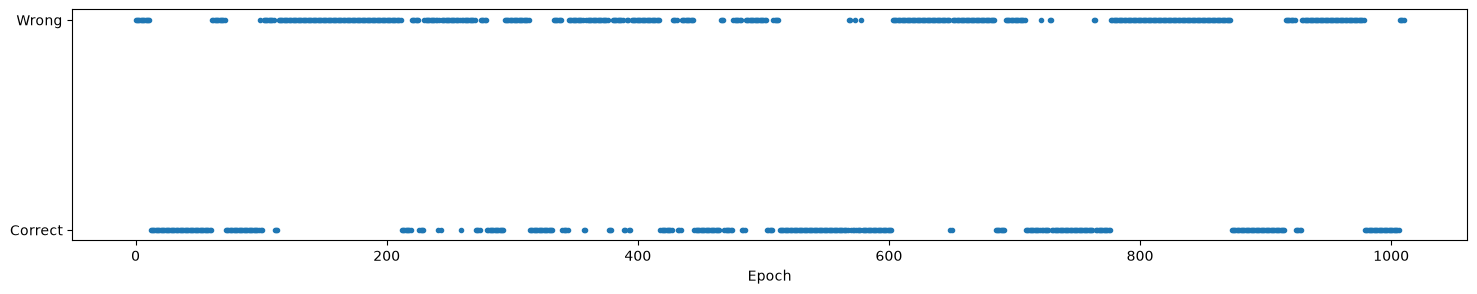

In [23]:
plt.figure(figsize=(18,3))

error = (
    df.y_true
    !=
    df.y_pred
)

plt.plot(
    error.astype(int),
    "."
)

plt.yticks(
    [0,1],
    ["Correct","Wrong"]
)

plt.xlabel("Epoch")

plt.show()

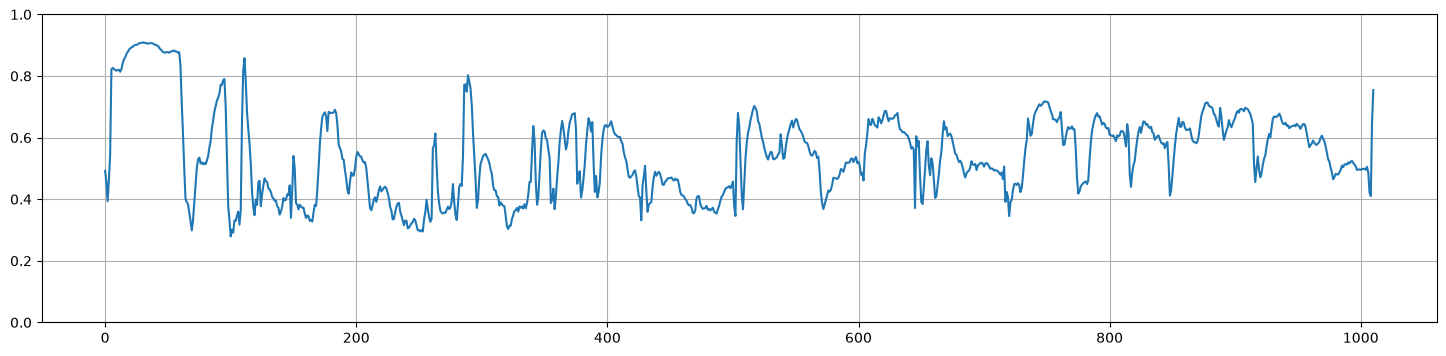

In [24]:
confidence = y_prob.max(axis=1)

df["confidence"] = confidence[df.index]

plt.figure(figsize=(18,4))

plt.plot(
    df.confidence.values
)

plt.ylim(0,1)

plt.grid(True)

plt.show()

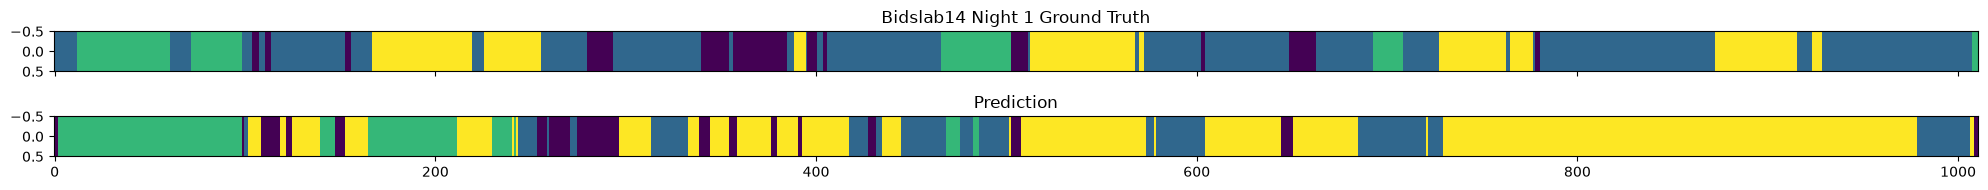

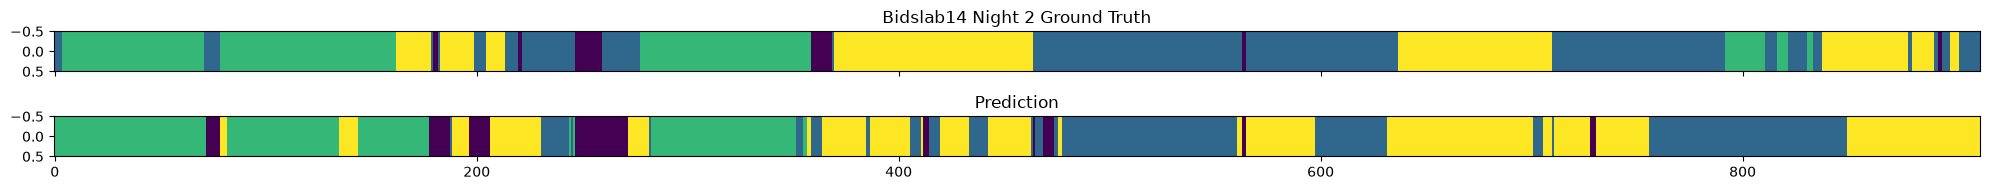

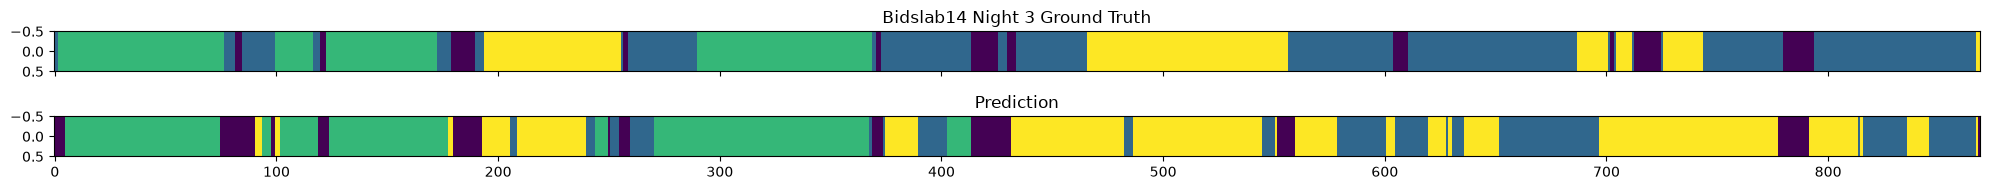

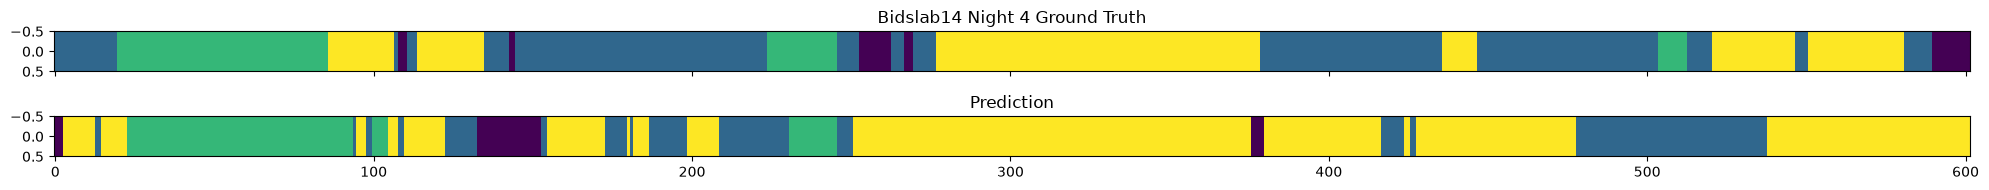

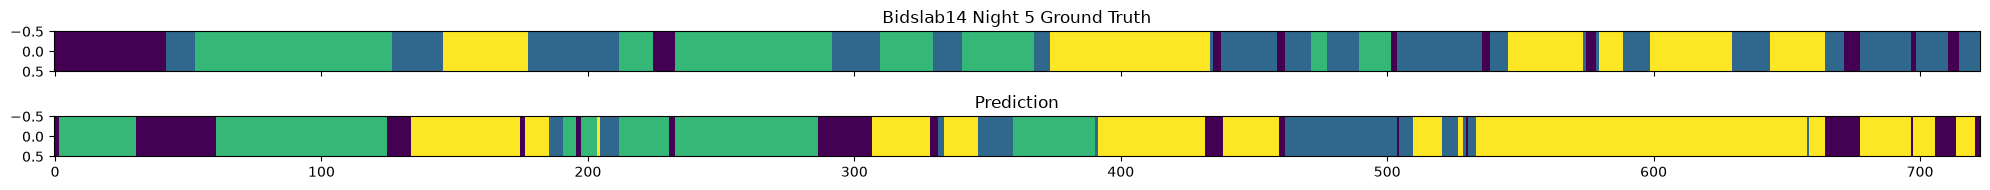

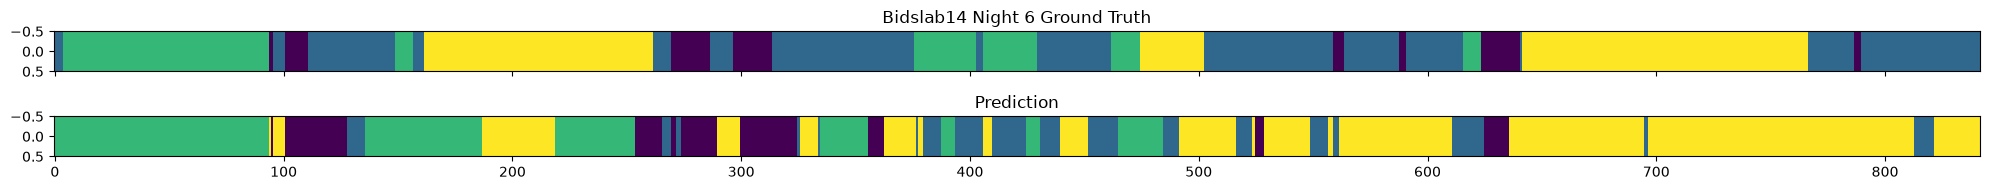

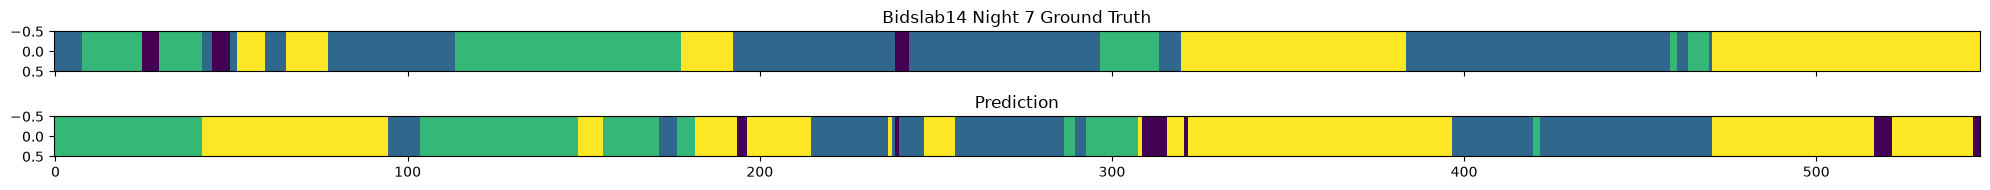

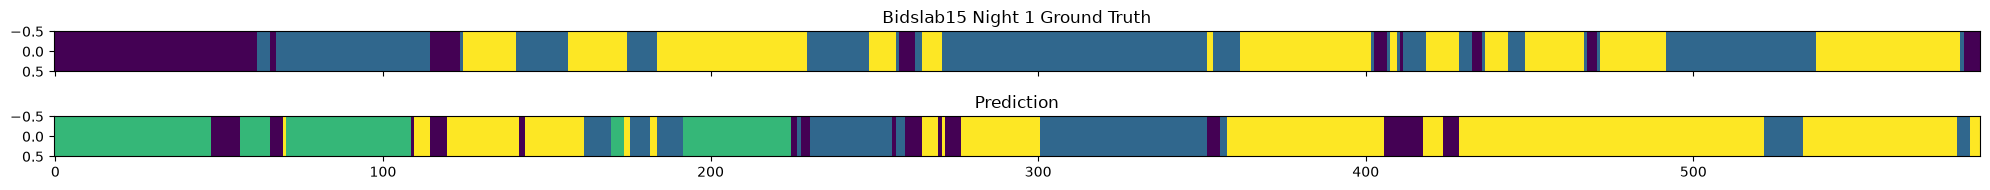

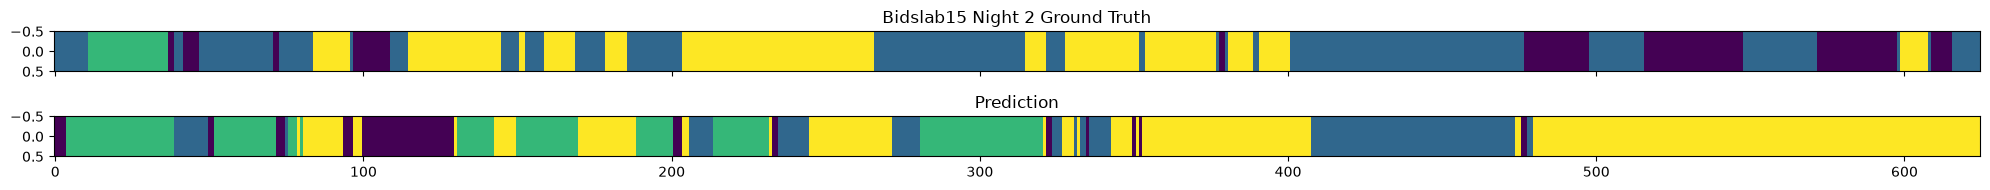

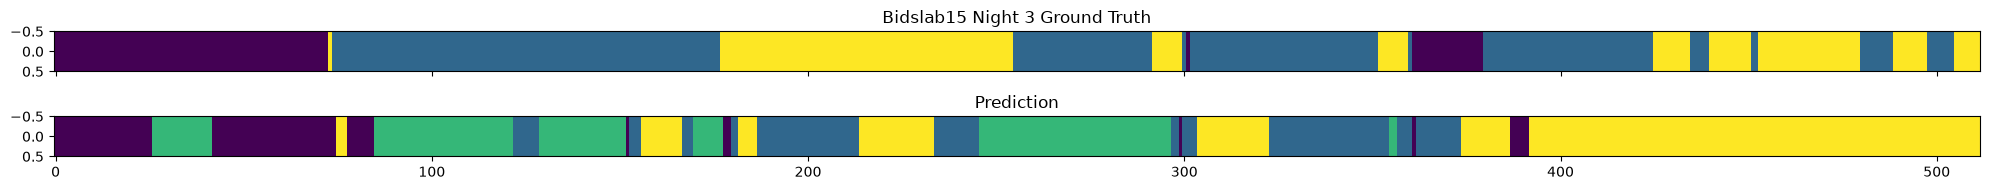

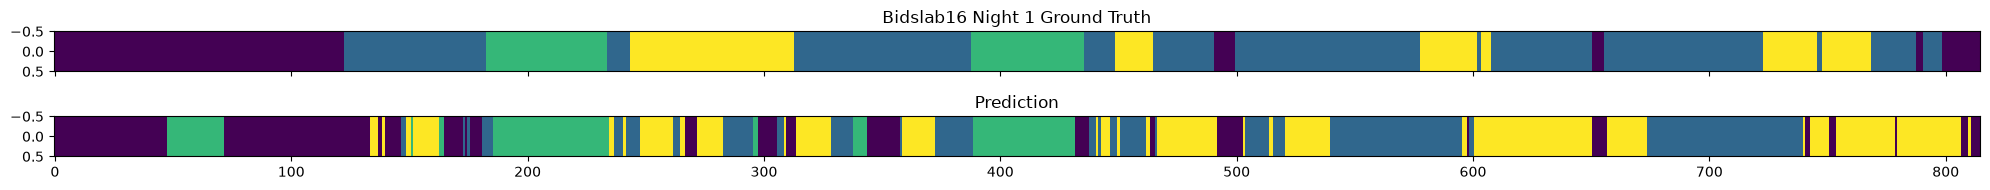

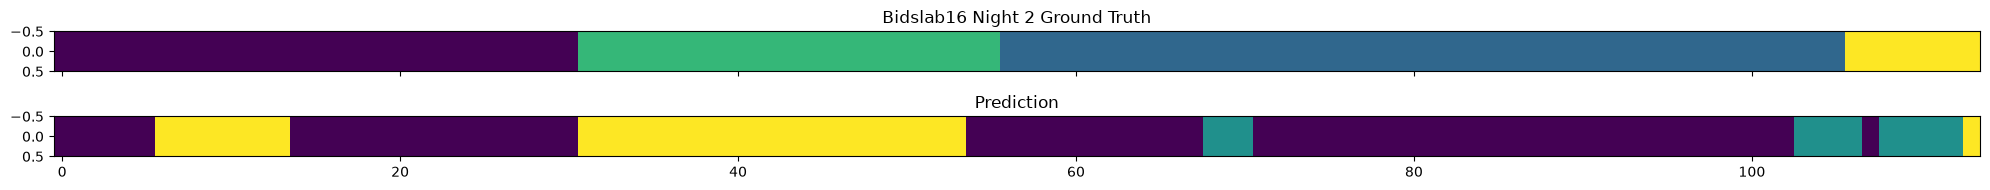

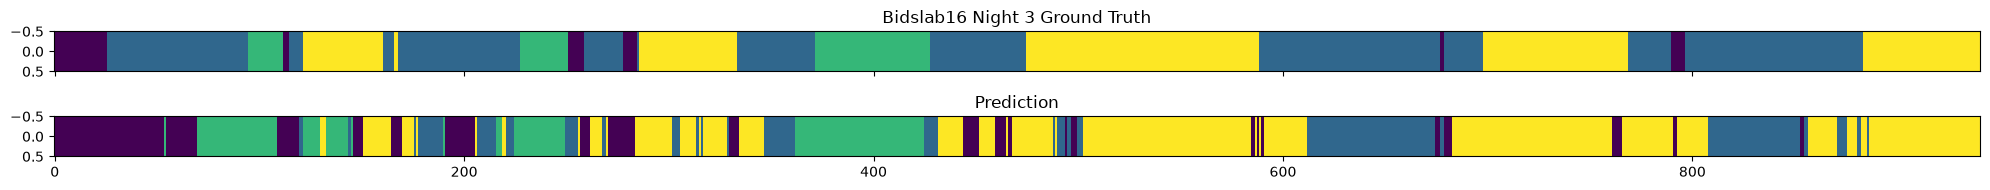

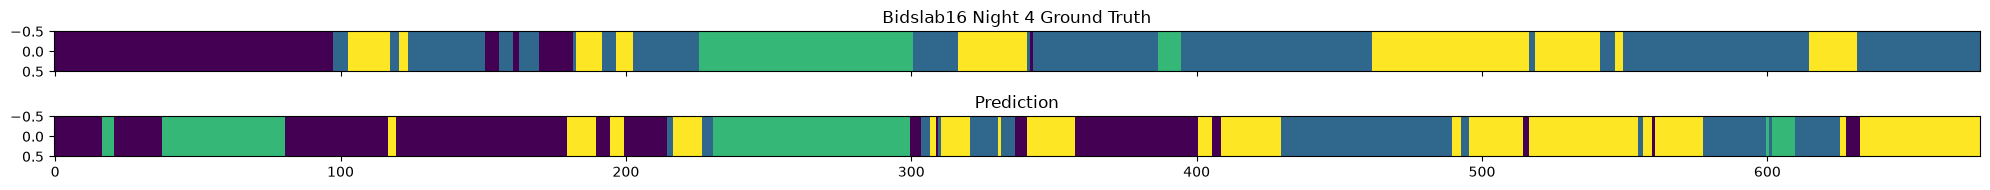

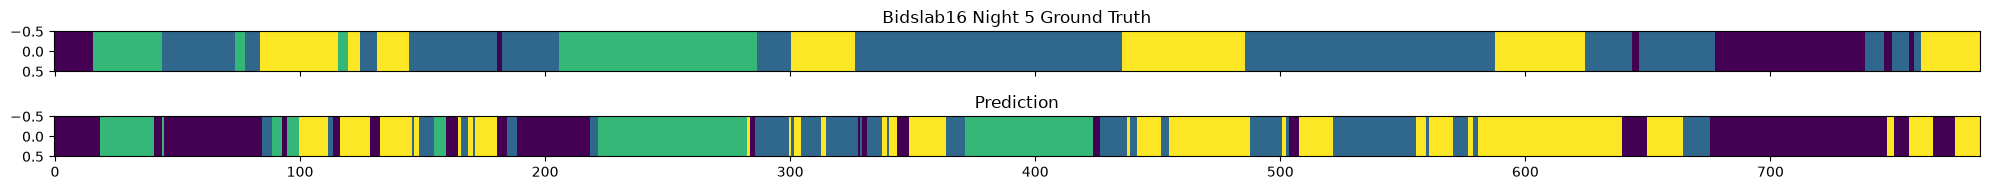

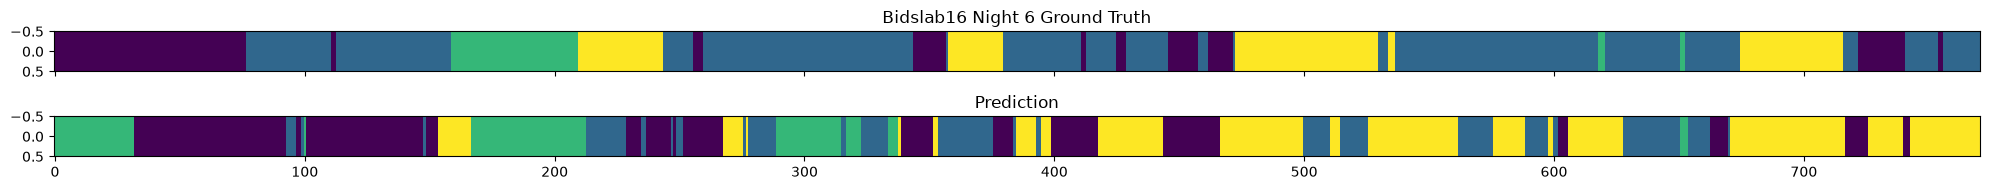

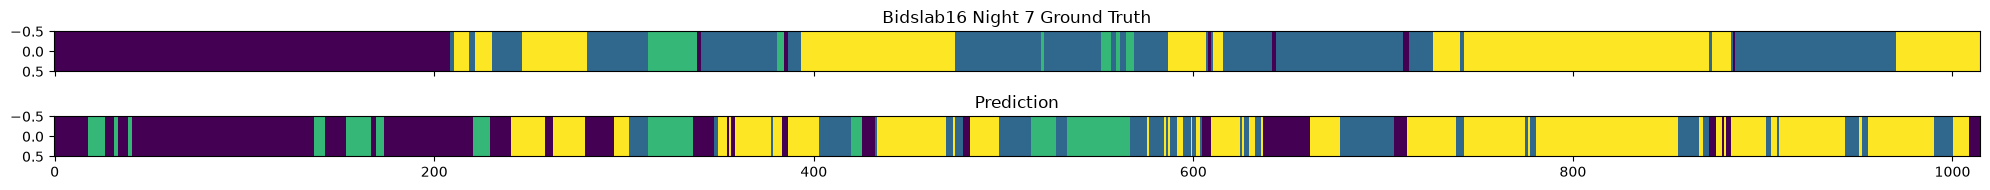

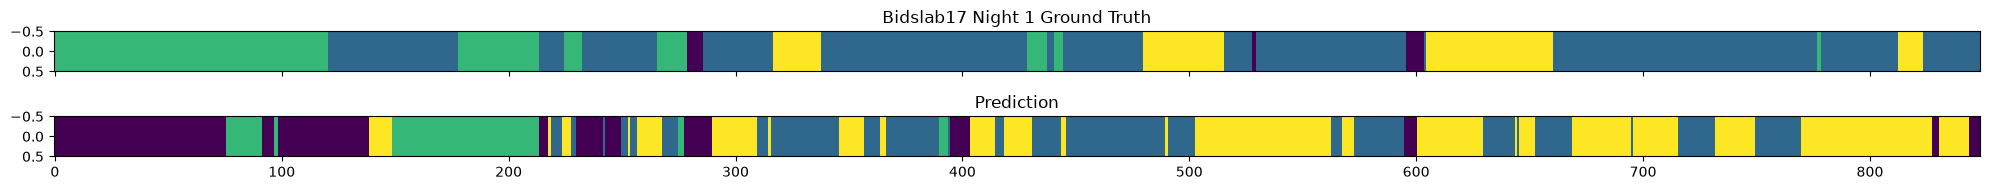

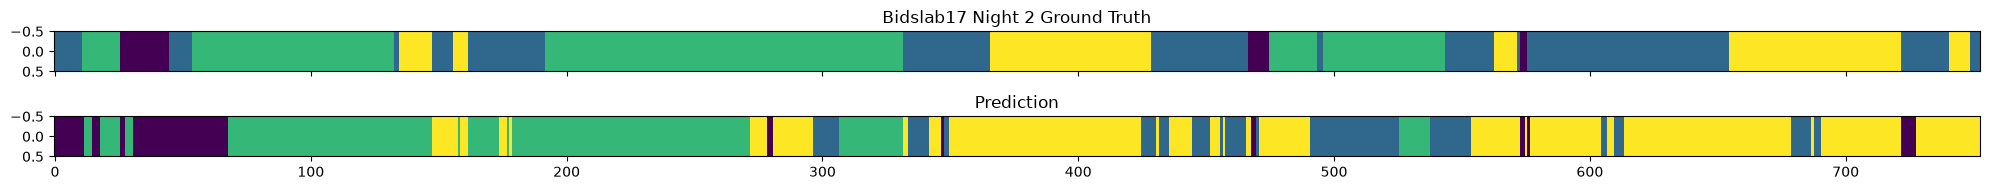

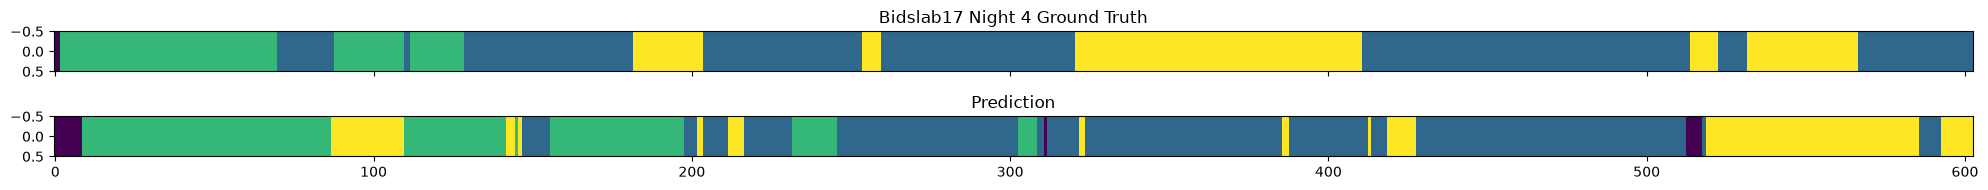

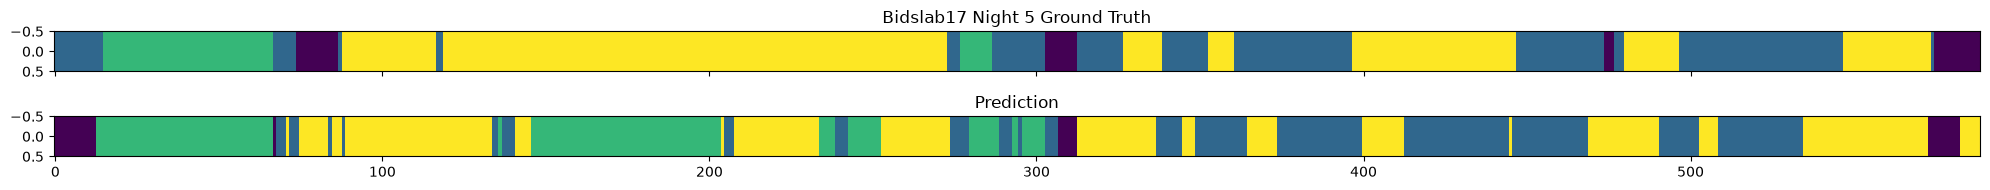

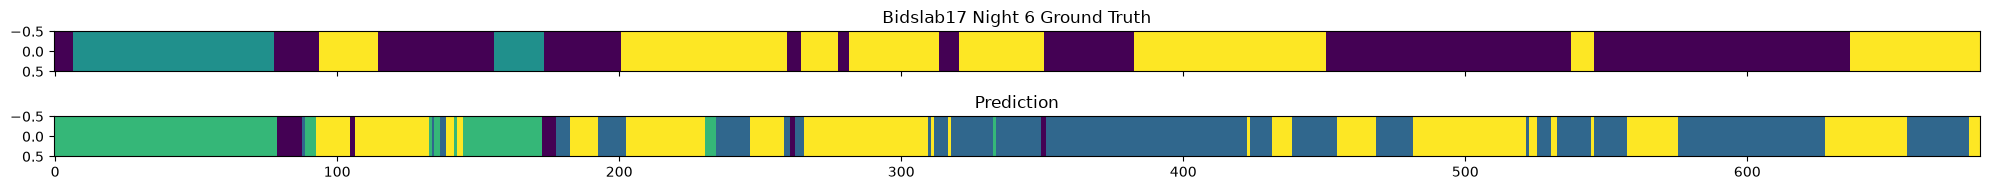

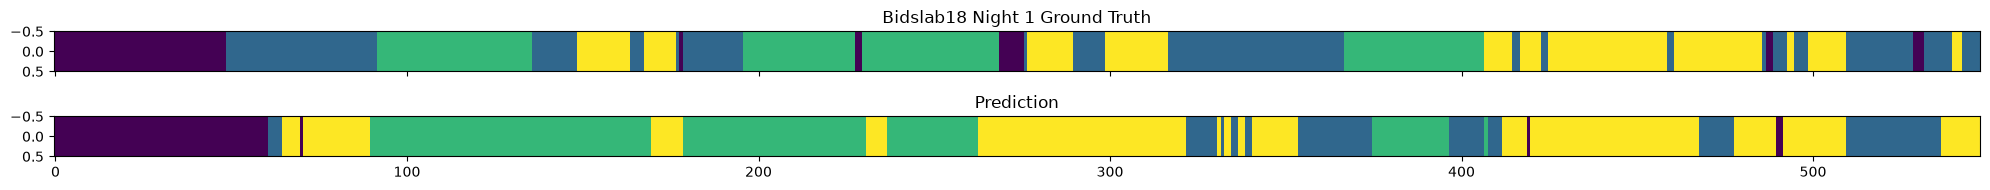

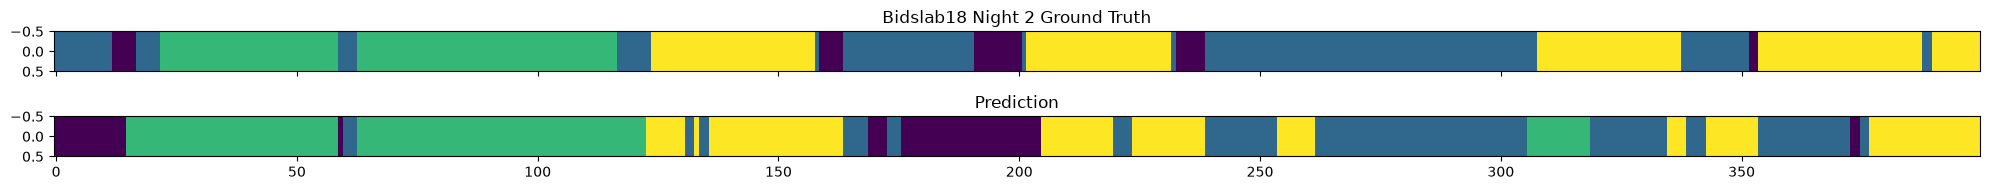

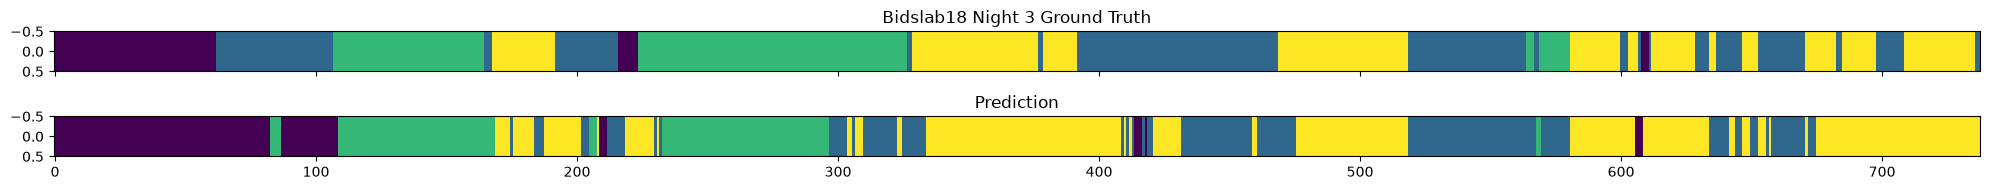

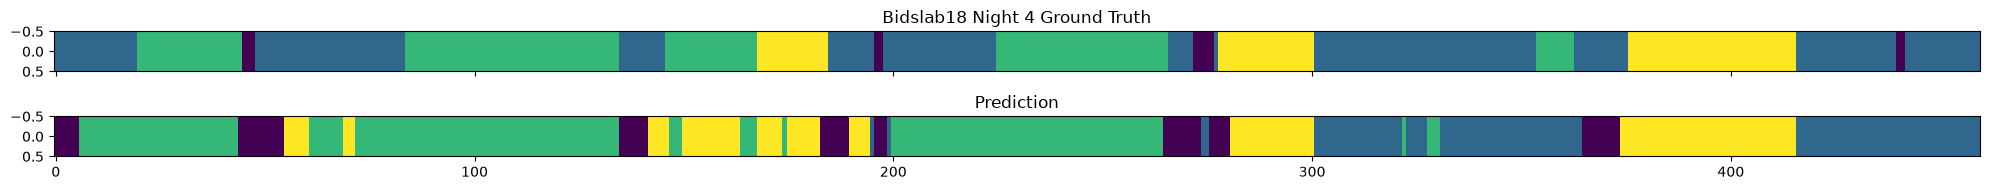

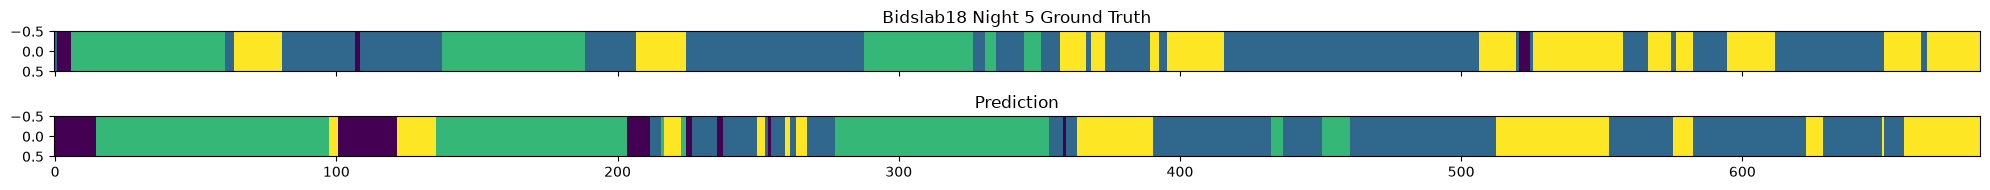

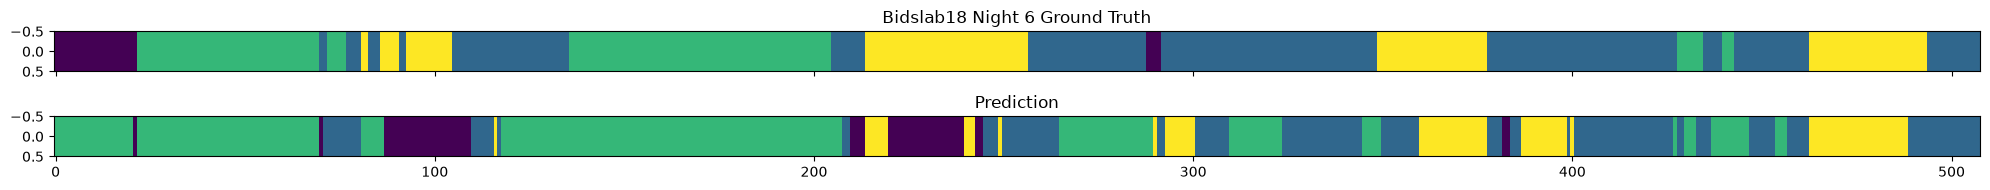

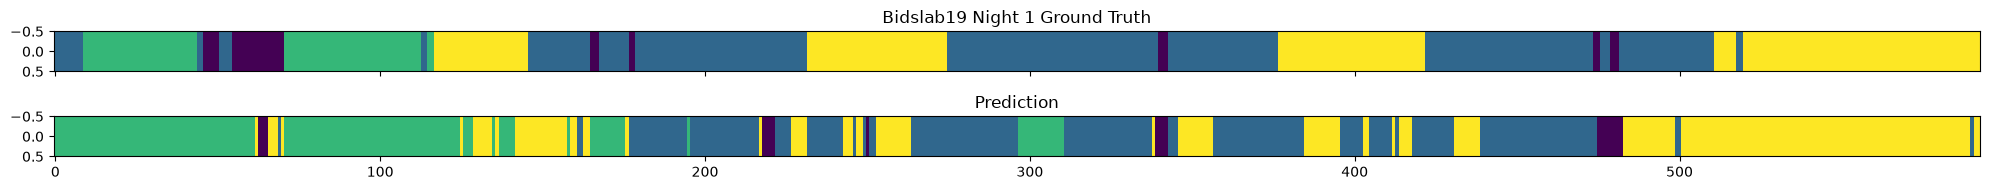

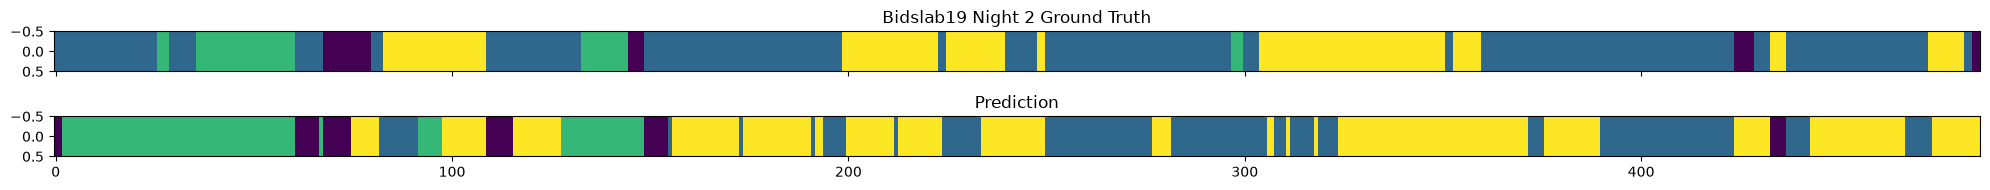

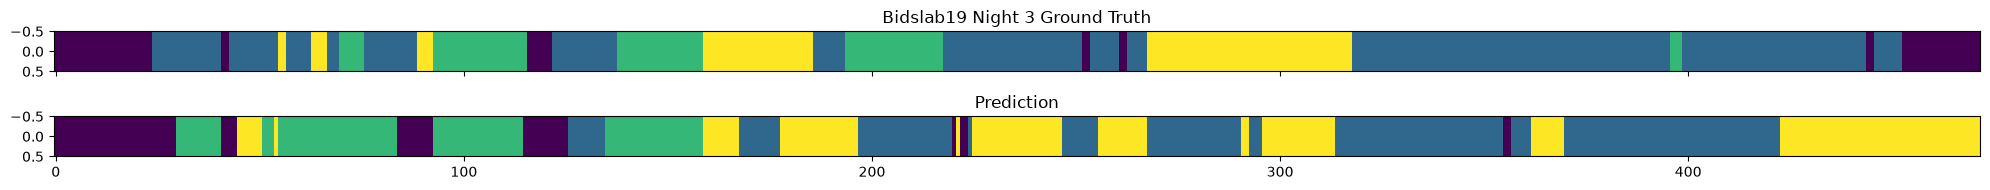

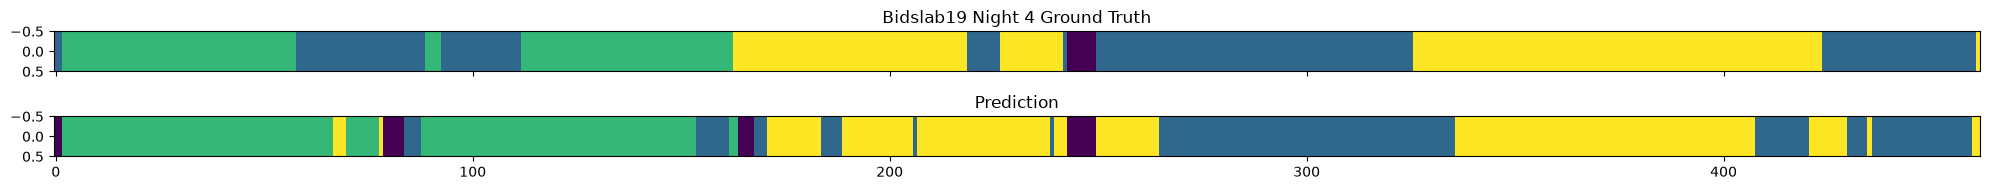

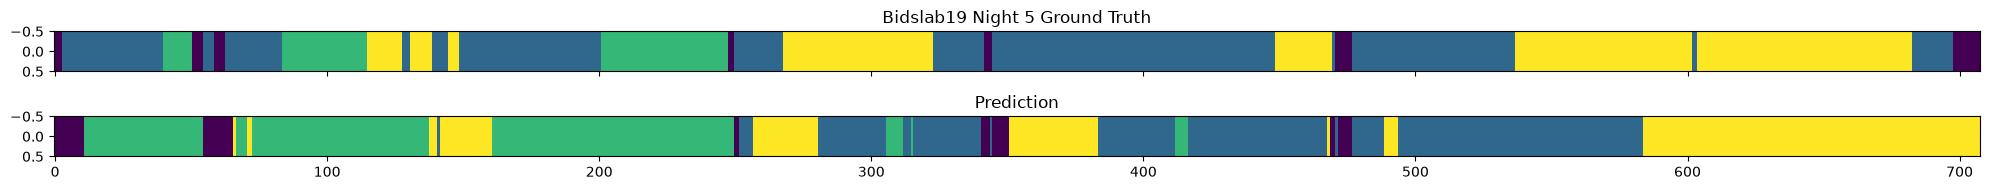

In [ ]:
for (subject, night), g in metadata.groupby(
    ["Subject","Night"]
):

    fig,ax = plt.subplots(
        2,
        1,
        figsize=(20,2),
        sharex=True
    )

    ax[0].imshow(
        g.y_true.values.reshape(1,-1),
        aspect="auto",
        interpolation="nearest"
    )

    ax[0].set_title(
        f"{subject} Night {night} Ground Truth"
    )

    ax[1].imshow(
        g.y_pred.values.reshape(1,-1),
        aspect="auto",
        interpolation="nearest"
    )

    ax[1].set_title(
        "Prediction"
    )

    plt.tight_layout()

    plt.show()